# **Linear regression**

Marek Šugár

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TestDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import LinearRegression

In [3]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TestDataFrame()

# **Linear regression**

a.k.a. plain and simple :)

In [4]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))

        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        


        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

In [5]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [6]:
np.mean(list(mean_performances.values()))
#1.8022770841893423

np.float64(1.8480000075563205)

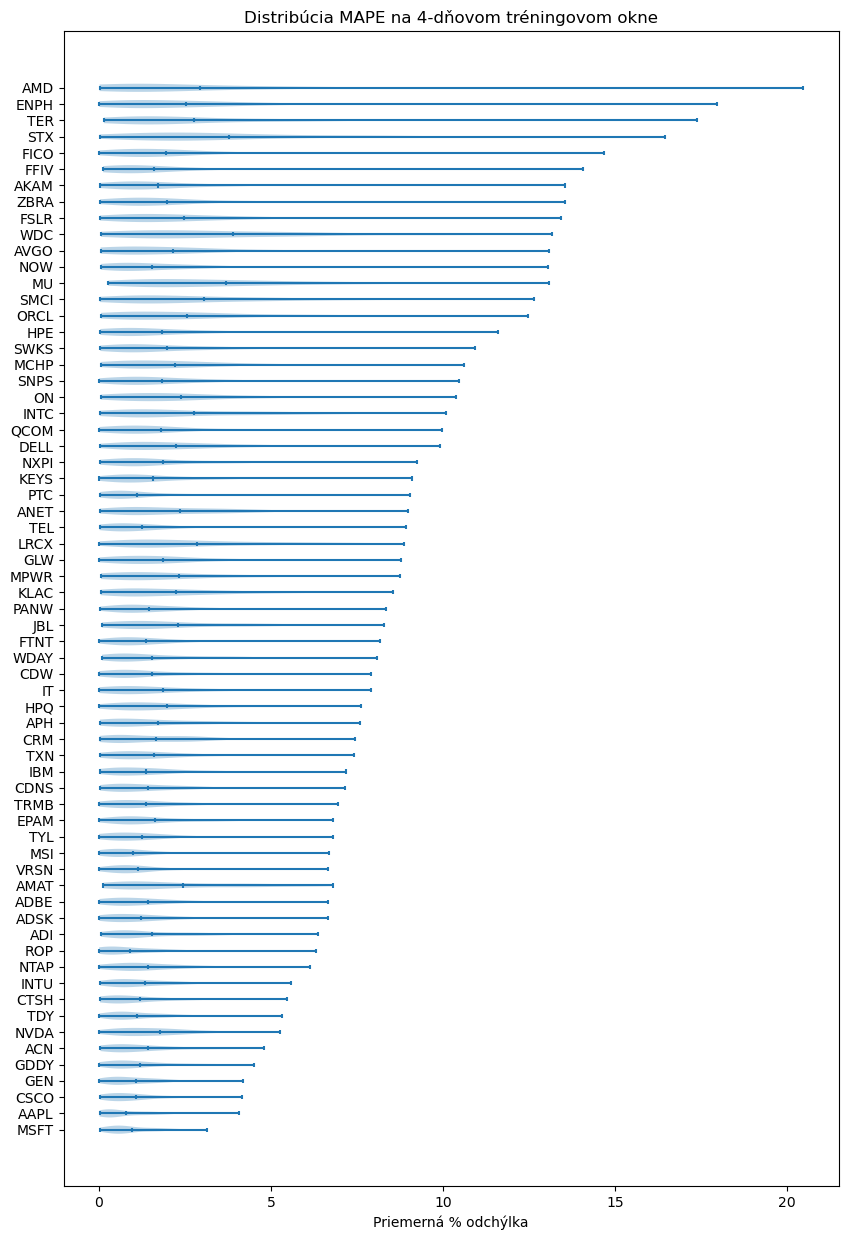

In [7]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [8]:
mean_performances

{'AAPL': np.float64(0.7987633451164176),
 'ROP': np.float64(0.9124934521684268),
 'MSFT': np.float64(0.9622938851994813),
 'MSI': np.float64(0.9937658611316192),
 'GEN': np.float64(1.076028258433476),
 'CSCO': np.float64(1.077031857895382),
 'PTC': np.float64(1.0948628526279232),
 'TDY': np.float64(1.1191906501435946),
 'VRSN': np.float64(1.130592354911623),
 'CTSH': np.float64(1.1808503169769047),
 'GDDY': np.float64(1.202481156384667),
 'ADSK': np.float64(1.2169207869837486),
 'TEL': np.float64(1.2484435840669414),
 'TYL': np.float64(1.2585066308525488),
 'INTU': np.float64(1.342699929956367),
 'IBM': np.float64(1.360370808054268),
 'TRMB': np.float64(1.3728725770068257),
 'FTNT': np.float64(1.3761995262933115),
 'CDNS': np.float64(1.4199286391739865),
 'ADBE': np.float64(1.4245605597843805),
 'ACN': np.float64(1.424760604643908),
 'NTAP': np.float64(1.4307901912535528),
 'PANW': np.float64(1.455488315319913),
 'WDAY': np.float64(1.5371400194750842),
 'NOW': np.float64(1.539836986844

In [9]:
np.mean([np.mean(i) for i in performance_simple.values()])
#0.4414159701090096

np.float64(0.43466407010710806)

# **Date-wise model dominance over naive**

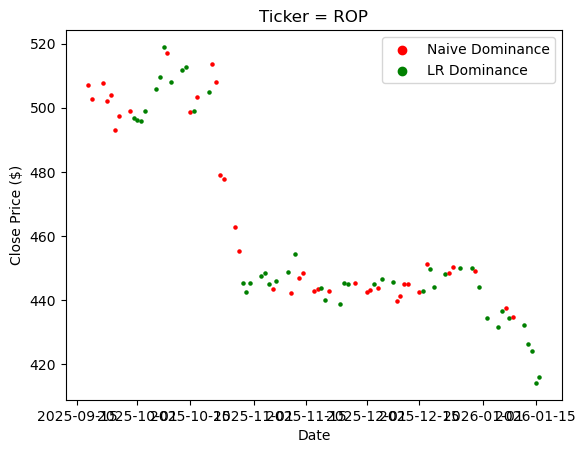

In [13]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=5)
    else:
        plt.scatter(date, close_price, c="red", s=5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "LR Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

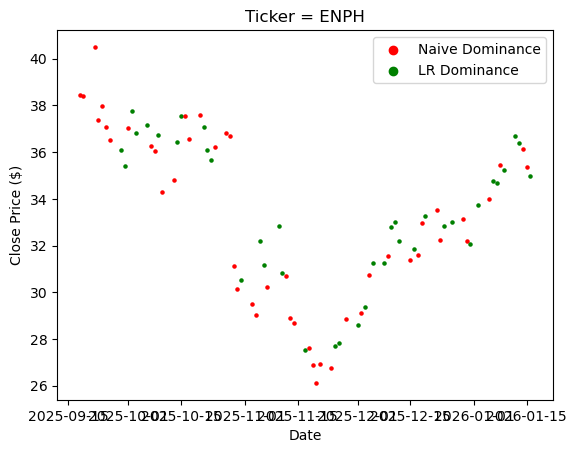

In [12]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=5)
    else:
        plt.scatter(date, close_price, c="red", s=5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "LR Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

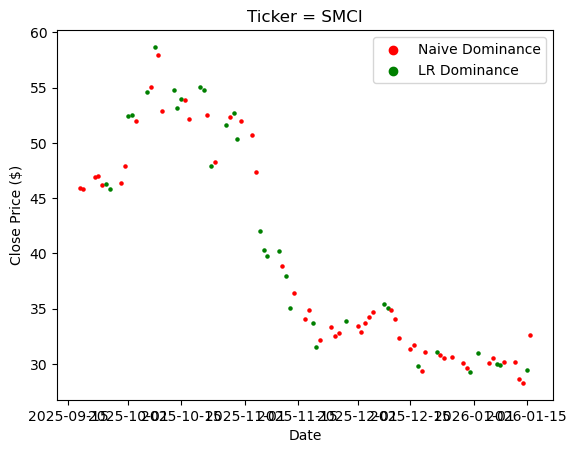

In [14]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=5)
    else:
        plt.scatter(date, close_price, c="red", s=5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "LR Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

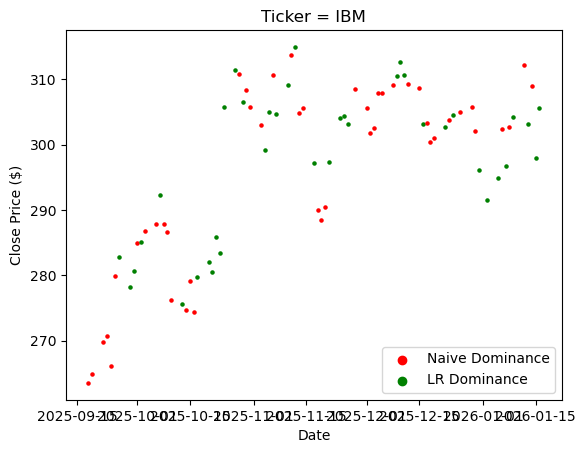

In [15]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=5)
    else:
        plt.scatter(date, close_price, c="red", s=5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "LR Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()